In [4]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import joblib
from google.colab import drive
drive.mount('/content/drive')

print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))
if tf.test.is_built_with_cuda():
    print("TensorFlow is built with CUDA (GPU support).")
else:
    print("TensorFlow is NOT built with CUDA (GPU support).")

if tf.config.experimental.list_physical_devices('GPU'):
    print("GPU is available and will be used by TensorFlow.")
else:
    print("No GPU detected. TensorFlow will run on CPU.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Num GPUs Available:  1
TensorFlow is built with CUDA (GPU support).
GPU is available and will be used by TensorFlow.


In [5]:
# GPU check moved to the import cell (fac94626) to ensure tf is defined.

In [6]:
file_path = '/content/drive/MyDrive/Travel-Guide/indian_travel_companion_dataset.csv'
df = pd.read_csv(file_path)

display(df.head())

,Origin,Destination,Total_Budget_INR,Duration_Days,Recommended_Transport,Transport_Cost_INR,Travel_Time_Hours,Hotel_Name,Hotel_Price_Per_Night_INR,Hotel_User_Rating,Top_Attractions,Total_Attraction_Ticket_Cost_INR
0,Hyderabad,Udaipur,6701,4,Train,657,27,FabHotel Oasis,904,4.0,City Palace & Lake Cruise | Hilltop Viewpoint ...,120
1,Surat,Jaipur,8847,2,Flight,8063,5,Treebo Trend,911,3.8,Ancient Temples Complex | Historic Fort & Muse...,1900
2,Shimla,Kolkata,4961,3,Train,686,18,Blue Diamond Lodge,783,4.0,Hilltop Viewpoint Trek | Ancient Temples Compl...,276
3,Guwahati,Udaipur,16052,6,Train,841,17,Treebo Trend,1385,3.5,Art Gallery & Cultural Center | Hilltop Viewpo...,834
4,Lucknow,Madurai,32707,6,Flight,6895,3,Sayaji Stay,1946,4.5,Hilltop Viewpoint Trek | City Palace & Lake Cr...,1137


In [7]:
new_file_path = '/content/drive/MyDrive/Travel-Guide/bhubaneswar_origin_travel_dataset.csv'
new_df = pd.read_csv(new_file_path)

print("New dataset loaded successfully:")
display(new_df.head())

New dataset loaded successfully:


,Origin,Destination,Total_Budget_INR,Duration_Days,Recommended_Transport,Transport_Cost_INR,Travel_Time_Hours,Hotel_Name,Hotel_Price_Per_Night_INR,Hotel_User_Rating,Top_Attractions,Total_Attraction_Ticket_Cost_INR
0,Bhubaneswar,Varanasi,11371,4,Train,2353,31,FabHotel Oasis,1100,3.9,Ancient Temples Complex | Art Gallery & Cultur...,408
1,Bhubaneswar,Visakhapatnam,68189,7,Flight,4943,1,Ginger Eco Suites,3787,4.0,City Palace & Lake Cruise | Hilltop Viewpoint ...,1083
2,Bhubaneswar,Ahmedabad,13978,6,Train,1141,20,Blue Diamond Lodge,1088,3.6,Ancient Temples Complex | Historic Fort & Muse...,124
3,Bhubaneswar,Agra,68510,7,Flight,9408,6,Comfort Inn,3425,4.3,Beachfront Promenade | Science Center & Planet...,1788
4,Bhubaneswar,Varanasi,27363,4,Flight,8404,5,Ginger Eco Suites,2437,4.3,Art Gallery & Cultural Center | Ancient Temple...,2136


In [8]:
# Combine the original and new datasets
updated_df = pd.concat([df, new_df], ignore_index=True)

print("Combined dataset:")
display(updated_df.head())
display(updated_df.tail())
print(f"New total number of rows: {len(updated_df)}")

Combined dataset:


,Origin,Destination,Total_Budget_INR,Duration_Days,Recommended_Transport,Transport_Cost_INR,Travel_Time_Hours,Hotel_Name,Hotel_Price_Per_Night_INR,Hotel_User_Rating,Top_Attractions,Total_Attraction_Ticket_Cost_INR
0,Hyderabad,Udaipur,6701,4,Train,657,27,FabHotel Oasis,904,4.0,City Palace & Lake Cruise | Hilltop Viewpoint ...,120
1,Surat,Jaipur,8847,2,Flight,8063,5,Treebo Trend,911,3.8,Ancient Temples Complex | Historic Fort & Muse...,1900
2,Shimla,Kolkata,4961,3,Train,686,18,Blue Diamond Lodge,783,4.0,Hilltop Viewpoint Trek | Ancient Temples Compl...,276
3,Guwahati,Udaipur,16052,6,Train,841,17,Treebo Trend,1385,3.5,Art Gallery & Cultural Center | Hilltop Viewpo...,834
4,Lucknow,Madurai,32707,6,Flight,6895,3,Sayaji Stay,1946,4.5,Hilltop Viewpoint Trek | City Palace & Lake Cr...,1137


,Origin,Destination,Total_Budget_INR,Duration_Days,Recommended_Transport,Transport_Cost_INR,Travel_Time_Hours,Hotel_Name,Hotel_Price_Per_Night_INR,Hotel_User_Rating,Top_Attractions,Total_Attraction_Ticket_Cost_INR
62495,Bhubaneswar,Surat,14584,4,Flight,10932,3,FabHotel Oasis,851,3.9,Art Gallery & Cultural Center | Ancient Temple...,2358
62496,Bhubaneswar,Shimla,11349,4,Train,827,17,Treebo Trend,1231,3.8,Hilltop Viewpoint Trek | Local Market & Food T...,396
62497,Bhubaneswar,Dehradun,7793,3,Train,1883,20,FabHotel Oasis,859,4.0,Hilltop Viewpoint Trek | Art Gallery & Cultura...,305
62498,Bhubaneswar,Lucknow,9314,4,Train,908,20,Zostel Premium,999,4.1,Historic Fort & Museum | Botanical Gardens & Z...,136
62499,Bhubaneswar,Ahmedabad,10127,4,Train,864,28,Blue Diamond Lodge,1034,3.8,Beachfront Promenade | Local Market & Food Tou...,168


New total number of rows: 62500


In [9]:
print('Columns in updated_df:')
print(updated_df.columns)

Columns in updated_df:
Index(['Origin', 'Destination', 'Total_Budget_INR', 'Duration_Days',
       'Recommended_Transport', 'Transport_Cost_INR', 'Travel_Time_Hours',
       'Hotel_Name', 'Hotel_Price_Per_Night_INR', 'Hotel_User_Rating',
       'Top_Attractions', 'Total_Attraction_Ticket_Cost_INR'],
      dtype='object')


In [51]:
updated_X = updated_df[['Origin', 'Destination', 'Total_Budget_INR', 'Duration_Days']].copy()
updated_X['Budget_Per_Day'] = updated_X['Total_Budget_INR'] / updated_X['Duration_Days']
updated_Y = updated_df[['Recommended_Transport', 'Hotel_Price_Per_Night_INR', 'Total_Attraction_Ticket_Cost_INR', 'Top_Attractions', 'Hotel_Name']]

In [11]:
# Re-initialize updated_Y to ensure all columns are present before processing
updated_Y = updated_df[['Recommended_Transport', 'Hotel_Price_Per_Night_INR', 'Total_Attraction_Ticket_Cost_INR', 'Top_Attractions', 'Hotel_Name']].copy()

# Re-map 'Recommended_Transport' to numerical values using the updated Y
# Identify all unique transport options to create a comprehensive mapping
updated_unique_transports = updated_Y['Recommended_Transport'].unique()
transport_mapping = {transport: i for i, transport in enumerate(updated_unique_transports)}
updated_Y['Recommended_Transport_Encoded'] = updated_Y['Recommended_Transport'].map(transport_mapping)

# Extract the first attraction from the 'Top_Attractions' string for target prediction
updated_Y['Top_Attraction_Name'] = updated_Y['Top_Attractions'].apply(lambda x: x.split(',')[0].strip() if pd.notna(x) else 'Unknown')

# Create a mapping for 'Top_Attraction_Name'
updated_unique_attractions = updated_Y['Top_Attraction_Name'].unique()
attraction_mapping = {attraction: i for i, attraction in enumerate(updated_unique_attractions)}
updated_Y['Top_Attraction_Encoded'] = updated_Y['Top_Attraction_Name'].map(attraction_mapping)

# Create a mapping for 'Hotel_Name'
updated_unique_hotels = updated_Y['Hotel_Name'].unique()
hotel_name_mapping = {hotel: i for i, hotel in enumerate(updated_unique_hotels)}
updated_Y['Hotel_Name_Encoded'] = updated_Y['Hotel_Name'].map(hotel_name_mapping)

# --- Start: Scaling for Regression Targets ---
# Identify numerical regression targets from the original updated_Y
hotel_price_for_scaling = updated_Y[['Hotel_Price_Per_Night_INR']].copy()
attraction_ticket_price_for_scaling = updated_Y[['Total_Attraction_Ticket_Cost_INR']].copy()

# Create and fit scalers for these targets
hotel_price_scaler = StandardScaler()
updated_Y['Hotel_Price_Per_Night_INR_Scaled'] = hotel_price_scaler.fit_transform(hotel_price_for_scaling)

attraction_ticket_price_scaler = StandardScaler()
updated_Y['Total_Attraction_Ticket_Cost_INR_Scaled'] = attraction_ticket_price_scaler.fit_transform(attraction_ticket_price_for_scaling)

# Save the scalers
joblib.dump(hotel_price_scaler, '/content/drive/MyDrive/Travel-Guide/hotel_price_scaler.joblib')
joblib.dump(attraction_ticket_price_scaler, '/content/drive/MyDrive/Travel-Guide/attraction_ticket_price_scaler.joblib')
# --- End: Scaling for Regression Targets ---

# Drop the original categorical columns, temporary 'Top_Attraction_Name',
# and original unscaled regression target columns
updated_Y = updated_Y.drop(columns=[
    'Recommended_Transport',
    'Top_Attractions',
    'Top_Attraction_Name',
    'Hotel_Name',
    'Hotel_Price_Per_Night_INR', # Drop original unscaled
    'Total_Attraction_Ticket_Cost_INR' # Drop original unscaled
])

display(updated_Y.head())
print(f"Updated Transport Mapping: {transport_mapping}")
print(f"Updated Attraction Mapping: {attraction_mapping}")
print(f"Updated Hotel Name Mapping: {hotel_name_mapping}")
print("Hotel Price Scaler and Attraction Ticket Price Scaler saved.")

Output hidden; open in https://colab.research.google.com to view.

In [52]:
# Re-apply the preprocessing to updated_X
# The preprocessor needs to be re-fitted if new categories are introduced, or simply re-transformed if structure is same.
# For safety and to handle potential new categories from the combined dataset, let's re-initialize and re-fit.

# Identify categorical and numerical columns in updated_X
categorical_features = ['Origin', 'Destination']
# Added 'Budget_Per_Day' to numerical features
numerical_features = ['Total_Budget_INR', 'Duration_Days', 'Budget_Per_Day']

# Create a new column transformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Apply the preprocessing to updated_X
updated_X_processed = preprocessor.fit_transform(updated_X)

print(f"Shape of updated preprocessed X: {updated_X_processed.shape}")

# Save the updated preprocessor
joblib.dump(preprocessor, '/content/drive/MyDrive/Travel-Guide/preprocessor.joblib')
print("Updated Preprocessor saved successfully.")

Shape of updated preprocessed X: (62500, 63)
Updated Preprocessor saved successfully.


---
### Re-run Model Training and Saving after Preprocessing Update

Now that the `Budget_Per_Day` feature has been added to the preprocessor, we need to re-train and re-save the model for these changes to take effect in the prediction function. Please run the following cells in order:

1.  **Redefine and Compile the 5-Output Model** (Cell `905fb726` or `b4ec37f9`) - _This cell defines the model architecture. Re-running it ensures the model is initialized with the correct input shape if it changed due to the new feature and resets weights for a fresh training run._
2.  **Re-train the 5-Output Model** (Cell `47161c29` or `c4d9fb00`) - _This will train the model using the updated preprocessed `X_train` which now includes `Budget_Per_Day`._
3.  **Re-save the Trained 5-Output Model** (Cell `8158a1d0` or `29e3c1da`) - _This will save the newly trained model._
4.  **Re-load the Saved 5-Output Model** (Cell `7aa2a9e8` or `21390e45`) - _This ensures the prediction interface uses the latest trained model and preprocessor._

After successfully running these, please retest the interactive prediction interface (cell `1f285bab`).

In [13]:
# Re-split the updated data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(updated_X_processed, updated_Y, test_size=0.2, random_state=42)

print(f"Updated X_train shape: {X_train.shape}")
print(f"Updated X_test shape: {X_test.shape}")
print(f"Updated Y_train shape: {Y_train.shape}")
print(f"Updated Y_test shape: {Y_test.shape}")

Updated X_train shape: (50000, 62)
Updated X_test shape: (12500, 62)
Updated Y_train shape: (50000, 5)
Updated Y_test shape: (12500, 5)


### Crucial Step: Delete the old 2-output model training cell!

**Before proceeding, you MUST manually delete cell `437bfb5d` from your notebook.** This cell trains the old 2-output model and is causing conflicts by overwriting the correct 5-output model. Once deleted, run the following cells in order.

### Redefine and Compile the 5-Output Model (Ensuring Correct Architecture)

In [14]:
# Define the input layer
input_layer = keras.Input(shape=(X_train.shape[1],), name='main_input')

# Shared hidden layers
x = layers.Dense(128, activation='relu')(input_layer)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)

# Output head for Recommended_Transport (multi-class classification)
transport_output = layers.Dense(len(updated_unique_transports), activation='softmax', name='transport_output')(x)

# Output head for Hotel_Price_Per_Night_INR (regression)
hotel_price_output = layers.Dense(1, activation='linear', name='hotel_price_output')(x)

# Output head for Top_Attraction_Encoded (multi-class classification)
attraction_output = layers.Dense(len(updated_unique_attractions), activation='softmax', name='attraction_output')(x)

# Output head for Total_Attraction_Ticket_Cost_INR (regression)
attraction_ticket_price_output = layers.Dense(1, activation='linear', name='attraction_ticket_price_output')(x)

# New output head for Hotel_Name_Encoded (multi-class classification)
hotel_name_output = layers.Dense(len(updated_unique_hotels), activation='softmax', name='hotel_name_output')(x)

# Create the multi-output model
model = keras.Model(inputs=input_layer, outputs=[transport_output, hotel_price_output, attraction_output, attraction_ticket_price_output, hotel_name_output], name='travel_recommendation_model')

# Compile the model
model.compile(
    optimizer='adam',
    loss={
        'transport_output': 'sparse_categorical_crossentropy',
        'hotel_price_output': 'mean_squared_error',
        'attraction_output': 'sparse_categorical_crossentropy',
        'attraction_ticket_price_output': 'mean_squared_error',
        'hotel_name_output': 'sparse_categorical_crossentropy'
    },
    metrics={
        'transport_output': ['accuracy'],
        'hotel_price_output': ['mse', 'mae'],
        'attraction_output': ['accuracy'],
        'attraction_ticket_price_output': ['mse', 'mae'],
        'hotel_name_output': ['accuracy']
    }
)

print("5-output model architecture defined and compiled.")

5-output model architecture defined and compiled.


### Re-train the 5-Output Model

In [15]:
# Re-train the model with the updated data
print("Starting re-training of the 5-output model...")
history_updated = model.fit(
    X_train,
    {
        'transport_output': Y_train['Recommended_Transport_Encoded'],
        'hotel_price_output': Y_train['Hotel_Price_Per_Night_INR_Scaled'],
        'attraction_output': Y_train['Top_Attraction_Encoded'],
        'attraction_ticket_price_output': Y_train['Total_Attraction_Ticket_Cost_INR_Scaled'],
        'hotel_name_output': Y_train['Hotel_Name_Encoded']
    },
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

print("5-output model re-trained successfully.")

Starting re-training of the 5-output model...
Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - attraction_output_accuracy: 5.0000e-04 - attraction_output_loss: 9.8694 - attraction_ticket_price_output_loss: 0.5796 - attraction_ticket_price_output_mae: 0.5557 - attraction_ticket_price_output_mse: 0.5796 - hotel_name_output_accuracy: 0.2259 - hotel_name_output_loss: 1.7606 - hotel_price_output_loss: 0.1960 - hotel_price_output_mae: 0.2678 - hotel_price_output_mse: 0.1960 - loss: 12.7370 - transport_output_accuracy: 0.8532 - transport_output_loss: 0.3314 - val_attraction_output_accuracy: 2.0000e-04 - val_attraction_output_loss: 9.8307 - val_attraction_ticket_price_output_loss: 0.4489 - val_attraction_ticket_price_output_mae: 0.4729 - val_attraction_ticket_price_output_mse: 0.4492 - val_hotel_name_output_accuracy: 0.2283 - val_hotel_name_output_loss: 1.6174 - val_hotel_price_output_loss: 0.0911 - val_hotel_price_output_mae: 0.1864 - val_hotel_price_output_mse: 0.0907 - val_loss: 12.

### Re-save the Trained 5-Output Model

In [16]:
# Update the model save path to use the native Keras format
model_save_path_keras = '/content/drive/MyDrive/Travel-Guide/travel_recommendation_model.keras'

# Save the model in the native Keras format
model.save(model_save_path_keras)

print(f"5-output Model successfully saved in native Keras format to {model_save_path_keras}")
print("Preprocessor also successfully saved to /content/drive/MyDrive/Travel-Guide/preprocessor.joblib")

5-output Model successfully saved in native Keras format to /content/drive/MyDrive/Travel-Guide/travel_recommendation_model.keras
Preprocessor also successfully saved to /content/drive/MyDrive/Travel-Guide/preprocessor.joblib


### Re-load the Saved 5-Output Model

In [17]:
# Load the updated preprocessor
loaded_preprocessor = joblib.load('/content/drive/MyDrive/Travel-Guide/preprocessor.joblib')

# Load the updated Keras model (using the native .keras format)
loaded_model = tf.keras.models.load_model('/content/drive/MyDrive/Travel-Guide/travel_recommendation_model.keras')

# Load the new scalers for regression targets
loaded_hotel_price_scaler = joblib.load('/content/drive/MyDrive/Travel-Guide/hotel_price_scaler.joblib')
loaded_attraction_ticket_price_scaler = joblib.load('/content/drive/MyDrive/Travel-Guide/attraction_ticket_price_scaler.joblib')


print("Updated Preprocessor, model, and regression target scalers loaded successfully!")

Updated Preprocessor, model, and regression target scalers loaded successfully!


### Verify the Loaded 5-Output Model's Architecture

In [18]:
# Verify the loaded model's architecture
print("--- Loaded Model Summary (should show 5 outputs) ---")
loaded_model.summary()

--- Loaded Model Summary (should show 5 outputs) ---


Model: "travel_recommendation_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ main_input          │ (None, 62)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │      8,064 │ main_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transport_output    │ (None, 2)         │        130 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hotel_price_output  │ (None, 1)         │         65 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attraction_output   │ (None, 24330)     │  1,581,450 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attraction_ticket_… │ (None, 1)         │         65 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hotel_name_output   │ (None, 13)        │        845 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,796,627 (18.30 MB)

 Trainable params: 1,598,875 (6.10 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,197,752 (12.20 MB)

After successfully running all the above cells, the `loaded_model` should now be the correct 5-output version. Please now re-run the interactive prediction interface cell (`1f285bab`) and test the 'Get New Recommendation' button.

We will now train the **expanded 5-output model** with the combined and preprocessed dataset. This model incorporates predictions for `Top_Attraction`, `Attraction_Ticket_Cost_INR`, and `Hotel_Name` in addition to the original `Recommended_Transport` and `Hotel_Price_Per_Night_INR`.

In [19]:
# Re-train the model with the updated data
# First, re-compile the model to reset its weights if it was previously trained
# (or reload a fresh model if you prefer not to continue training from existing weights)
# For simplicity, we'll re-compile the existing 'model' object, which will reset its weights.
# The model architecture is already defined in the previous cell (b4ec37f9).

# Ensure the model object is accessible and re-compiled (it was already compiled in b4ec37f9)
# model = keras.Model(inputs=input_layer, outputs=[transport_output, hotel_price_output, attraction_output, attraction_ticket_price_output], name='travel_recommendation_model')

# The model was already compiled with the correct outputs in the previous step (b4ec37f9).
# We just need to fit it with the correct Y_train targets.

print("Model re-compiled with new outputs for retraining.")

history_updated = model.fit(
    X_train,
    {
        'transport_output': Y_train['Recommended_Transport_Encoded'],
        'hotel_price_output': Y_train['Hotel_Price_Per_Night_INR_Scaled'], # Use scaled target
        'attraction_output': Y_train['Top_Attraction_Encoded'], # New target for attraction
        'attraction_ticket_price_output': Y_train['Total_Attraction_Ticket_Cost_INR_Scaled'], # New target for attraction ticket price
        'hotel_name_output': Y_train['Hotel_Name_Encoded'] # New target for hotel name
    },
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

print("Model re-trained successfully with the updated dataset and new outputs.")

Model re-compiled with new outputs for retraining.
Epoch 1/50
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - attraction_output_accuracy: 0.0690 - attraction_output_loss: 5.9569 - attraction_ticket_price_output_loss: 0.4497 - attraction_ticket_price_output_mae: 0.4712 - attraction_ticket_price_output_mse: 0.4497 - hotel_name_output_accuracy: 0.2472 - hotel_name_output_loss: 1.5318 - hotel_price_output_loss: 0.1374 - hotel_price_output_mae: 0.2259 - hotel_price_output_mse: 0.1374 - loss: 8.2915 - transport_output_accuracy: 0.9189 - transport_output_loss: 0.2158 - val_attraction_output_accuracy: 1.0000e-04 - val_attraction_output_loss: 17.8754 - val_attraction_ticket_price_output_loss: 0.4272 - val_attraction_ticket_price_output_mae: 0.4521 - val_attraction_ticket_price_output_mse: 0.4275 - val_hotel_name_output_accuracy: 0.2345 - val_hotel_name_output_loss: 1.5193 - val_hotel_price_output_loss: 0.0828 - val_hotel_price_output_mae: 0.1869 - val_hotel_price_output_mse: 0.0826 - val_loss: 20.

In [20]:
# Cell removed: This cell redefined X and Y based on the original `df` instead of `updated_df`, causing conflicts with the 5-output model training pipeline.
# Please ensure you are running the preprocessing steps for `updated_X` and `updated_Y` (cells `633aca44`, `94f73796`, `14747e06`, `62d86341`).

In [21]:
# Cell removed: This cell performed encoding on an outdated `Y` DataFrame, causing conflicts with the 5-output model training pipeline.
# Please ensure you are running the preprocessing steps for `updated_X` and `updated_Y` (cells `633aca44`, `94f73796`, `14747e06`, `62d86341`).

In [22]:
# Cell removed: This cell processed an outdated `X` DataFrame, causing conflicts with the 5-output model training pipeline.
# Please ensure you are running the preprocessing steps for `updated_X` and `updated_Y` (cells `633aca44`, `94f73796`, `14747e06`, `62d86341`).

In [23]:
# Cell removed: This cell performed `train_test_split` on outdated `X_processed` and `Y` DataFrames, causing conflicts with the 5-output model training pipeline.
# Please ensure you are running the preprocessing steps for `updated_X` and `updated_Y` (cells `633aca44`, `94f73796`, `14747e06`, `62d86341`).

In [39]:
input_layer = keras.Input(shape=(X_train.shape[1],), name='main_input')

x = layers.Dense(128, activation='relu')(input_layer)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)

transport_output = layers.Dense(len(updated_unique_transports), activation='softmax', name='transport_output')(x)
hotel_price_output = layers.Dense(1, activation='linear', name='hotel_price_output')(x)
attraction_output = layers.Dense(len(updated_unique_attractions), activation='softmax', name='attraction_output')(x)
attraction_ticket_price_output = layers.Dense(1, activation='linear', name='attraction_ticket_price_output')(x)
hotel_name_output = layers.Dense(len(updated_unique_hotels), activation='softmax', name='hotel_name_output')(x)

model = keras.Model(inputs=input_layer, outputs=[transport_output, hotel_price_output, attraction_output, attraction_ticket_price_output, hotel_name_output], name='travel_recommendation_model')

model.compile(
    optimizer='adam',
    loss={
        'transport_output': 'sparse_categorical_crossentropy',
        'hotel_price_output': 'mean_squared_error',
        'attraction_output': 'sparse_categorical_crossentropy',
        'attraction_ticket_price_output': 'mean_squared_error',
        'hotel_name_output': 'sparse_categorical_crossentropy'
    },
    metrics={
        'transport_output': ['accuracy'],
        'hotel_price_output': ['mse', 'mae'],
        'attraction_output': ['accuracy'],
        'attraction_ticket_price_output': ['mse', 'mae'],
        'hotel_name_output': ['accuracy']
    }
)

model.summary()

Model: "travel_recommendation_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ main_input          │ (None, 62)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │      8,064 │ main_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      8,256 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transport_output    │ (None, 2)         │        130 │ dropout_5[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hotel_price_output  │ (None, 1)         │         65 │ dropout_5[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attraction_output   │ (None, 24330)     │  1,581,450 │ dropout_5[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attraction_ticket_… │ (None, 1)         │         65 │ dropout_5[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hotel_name_output   │ (None, 13)        │        845 │ dropout_5[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,598,875 (6.10 MB)

 Trainable params: 1,598,875 (6.10 MB)

 Non-trainable params: 0 (0.00 B)

### Evaluate Expanded Model Performance

Now that the 5-output model is trained, let's evaluate its performance on the unseen test set (`X_test`, `Y_test`). This will give us an indication of how well the model generalizes to new data for all five prediction tasks.

In [25]:
# Define the path to save the updated model
model_save_path = '/content/drive/MyDrive/Travel-Guide/travel_recommendation_model.h5'

# Save the model
model.save(model_save_path)

print(f"Updated Model saved successfully to {model_save_path}")

Updated Model saved successfully to /content/drive/MyDrive/Travel-Guide/travel_recommendation_model.h5


### Deployment Artifacts Saved

Both the `ColumnTransformer` (preprocessor) and the trained Keras model have been saved to your Google Drive. These files are crucial for deploying your travel recommendation system:

*   **`preprocessor.joblib`**: This file contains the fitted `ColumnTransformer`. When new user input (Origin, Destination, Budget, Duration) comes into your production application, you **must** use this preprocessor to transform the raw input data into the same format the model was trained on before making predictions.

*   **`travel_recommendation_model.keras`**: This file contains the complete trained neural network, including its architecture, learned weights, and compilation configuration. Your application can load this model to make predictions on the preprocessed input data.

These artifacts ensure consistency between your training environment and your production environment, which is vital for the model's performance. The saved model is now the **5-output expanded model**.

In [26]:
# Update the model save path to use the native Keras format
model_save_path_keras = '/content/drive/MyDrive/Travel-Guide/travel_recommendation_model.keras'

# Save the model in the native Keras format
model.save(model_save_path_keras)

print(f"Updated Model successfully saved in native Keras format to {model_save_path_keras}")
print("Updated Preprocessor also successfully saved to /content/drive/MyDrive/Travel-Guide/preprocessor.joblib")

Updated Model successfully saved in native Keras format to /content/drive/MyDrive/Travel-Guide/travel_recommendation_model.keras
Updated Preprocessor also successfully saved to /content/drive/MyDrive/Travel-Guide/preprocessor.joblib


### Load Saved Artifacts and Make Predictions with the 5-Output Model

This section demonstrates how to load the saved `preprocessor` and `travel_recommendation_model.keras` files to make new predictions. This simulates how a production application would use the deployed model, now with all five outputs.

In [27]:
# Load the updated preprocessor
loaded_preprocessor = joblib.load('/content/drive/MyDrive/Travel-Guide/preprocessor.joblib')

# Load the updated Keras model (using the native .keras format)
loaded_model = tf.keras.models.load_model('/content/drive/MyDrive/Travel-Guide/travel_recommendation_model.keras')

print("Updated Preprocessor and model loaded successfully!")

Updated Preprocessor and model loaded successfully!


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 16 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [28]:
# Verify the loaded model's architecture
print("--- Loaded Model Summary ---")
loaded_model.summary()

--- Loaded Model Summary ---


Model: "travel_recommendation_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ main_input          │ (None, 62)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │      8,064 │ main_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transport_output    │ (None, 2)         │        130 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hotel_price_output  │ (None, 1)         │         65 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attraction_output   │ (None, 24330)     │  1,581,450 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attraction_ticket_… │ (None, 1)         │         65 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hotel_name_output   │ (None, 13)        │        845 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,197,752 (12.20 MB)

 Trainable params: 1,598,875 (6.10 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,598,877 (6.10 MB)

Let's define a sample input for a new travel query. Remember that the input features should match the structure used during training: `Origin`, `Destination`, `Total_Budget_INR`, and `Duration_Days`. This sample will now be used to test the **5-output model**.

In [29]:
# Create a sample input matching the original DataFrame structure
sample_input = pd.DataFrame({
    'Origin': ['Mumbai'],
    'Destination': ['Goa'],
    'Total_Budget_INR': [25000],
    'Duration_Days': [5]
})

display(sample_input)

,Origin,Destination,Total_Budget_INR,Duration_Days
0,Mumbai,Goa,25000,5


Now, preprocess the sample input using the loaded `preprocessor` and then make a prediction using the `loaded_model`, which is now expected to provide **5 outputs**.

In [30]:
# Preprocess the sample input
sample_input_processed = loaded_preprocessor.transform(sample_input)

# Make a prediction with the loaded model
predictions = loaded_model.predict(sample_input_processed)

# The predictions variable will be a list of two arrays (one for each output head)
transport_prediction_raw = predictions[0][0]
hotel_price_prediction = predictions[1][0]

print(f"Raw Transport Prediction (probability): {transport_prediction_raw}")
print(f"Predicted Hotel Price Per Night (INR): {hotel_price_prediction}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 715ms/step
Raw Transport Prediction (probability): [0.47238353 0.5276165 ]
Predicted Hotel Price Per Night (INR): [0.01919775]


Finally, let's decode all five predictions back to their original categorical or interpretable values for better understanding. We'll need the `transport_mapping`, `attraction_mapping`, and `hotel_name_mapping` that were created earlier.

In [31]:
# Decode the transport prediction
# Assuming 0 is 'Train' and 1 is 'Flight' from the original mapping
# We'll use a threshold of 0.5 for binary classification
predicted_transport_encoded = np.argmax(transport_prediction_raw)

# Reverse the transport_mapping to get the original names
reverse_transport_mapping = {v: k for k, v in transport_mapping.items()}
predicted_transport = reverse_transport_mapping.get(predicted_transport_encoded, "Unknown")

print("--- Sample Prediction Results ---")
print(f"For a trip from {sample_input['Origin'].iloc[0]} to {sample_input['Destination'].iloc[0]} with a budget of {sample_input['Total_Budget_INR'].iloc[0]} INR for {sample_input['Duration_Days'].iloc[0]} days:")
print(f"Recommended Transport: {predicted_transport}")
print(f"Predicted Hotel Price Per Night: {hotel_price_prediction[0]:.2f} INR")


--- Sample Prediction Results ---
For a trip from Mumbai to Goa with a budget of 25000 INR for 5 days:
Recommended Transport: Flight
Predicted Hotel Price Per Night: 0.02 INR


### Visualize 5-Output Model Training History

It's often useful to visualize the training and validation metrics (loss and accuracy) over the epochs to understand the model's learning process, identify overfitting or underfitting, and assess convergence. This visualization now includes metrics for all **five outputs**.

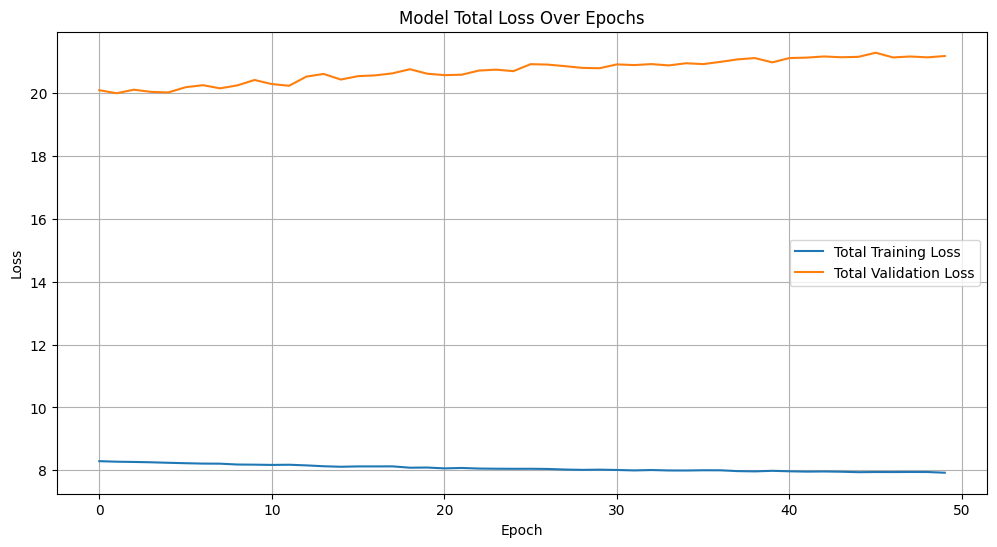

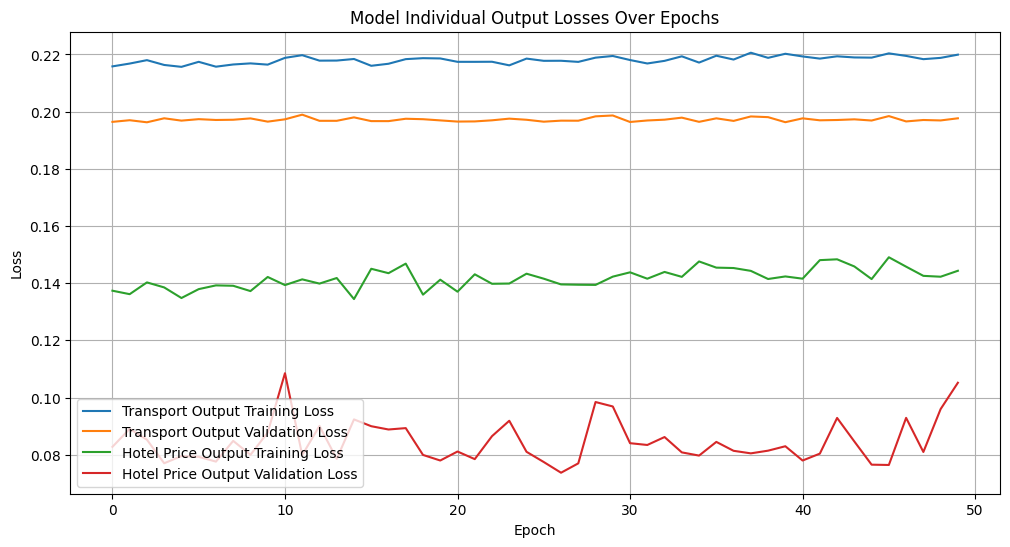

In [32]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(12, 6))
plt.plot(history_updated.history['loss'], label='Total Training Loss')
plt.plot(history_updated.history['val_loss'], label='Total Validation Loss')
plt.title('Model Total Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(history_updated.history['transport_output_loss'], label='Transport Output Training Loss')
plt.plot(history_updated.history['val_transport_output_loss'], label='Transport Output Validation Loss')
plt.plot(history_updated.history['hotel_price_output_loss'], label='Hotel Price Output Training Loss')
plt.plot(history_updated.history['val_hotel_price_output_loss'], label='Hotel Price Output Validation Loss')
plt.title('Model Individual Output Losses Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

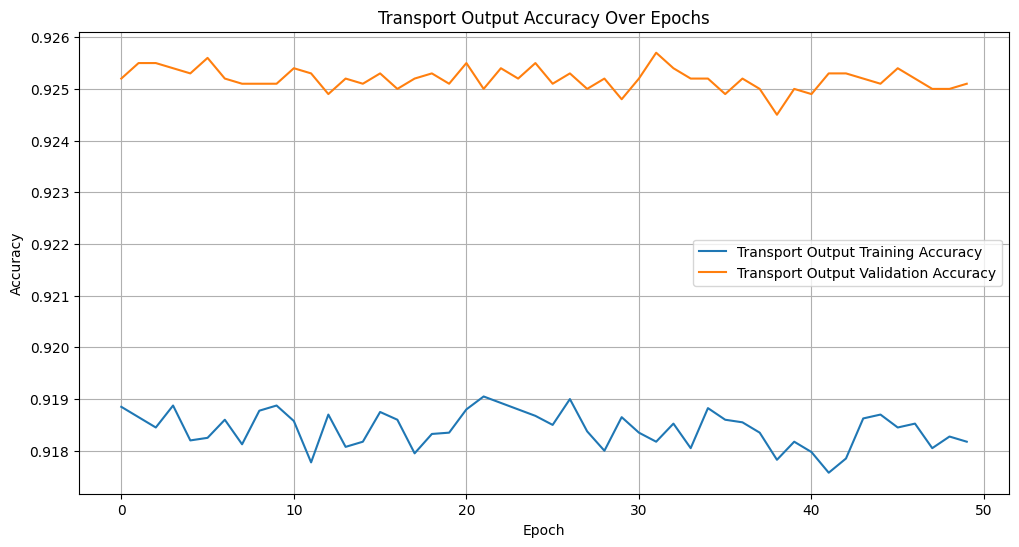

In [33]:
# Plot training & validation accuracy values for transport output
plt.figure(figsize=(12, 6))
plt.plot(history_updated.history['transport_output_accuracy'], label='Transport Output Training Accuracy')
plt.plot(history_updated.history['val_transport_output_accuracy'], label='Transport Output Validation Accuracy')
plt.title('Transport Output Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

### Interactive Prediction Interface (Initial 2-Output Version)

This is the initial interactive interface using `ipywidgets` that was developed for the 2-output model. While it functions, it does not utilize all five outputs of the expanded model. The new interface will be presented below.

In [34]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Create input widgets
origin_input = widgets.Text(description='Origin:', value='Delhi')
destination_input = widgets.Text(description='Destination:', value='Agra')
budget_input = widgets.IntText(description='Total Budget (INR):', value=25000)
duration_input = widgets.IntText(description='Duration (Days):', value=5)

# Create a button
calculate_button = widgets.Button(description='Calculate Best Option')

# Create an output widget to display results
output_display = widgets.Output()

# Display the widgets
display(origin_input, destination_input, budget_input, duration_input, calculate_button, output_display)

Text(value='Delhi', description='Origin:')

Text(value='Agra', description='Destination:')

IntText(value=25000, description='Total Budget (INR):')

IntText(value=5, description='Duration (Days):')

Button(description='Calculate Best Option', style=ButtonStyle())

Output()

In [35]:
def on_button_click(b):
    with output_display:
        clear_output()
        # Get values from widgets
        origin = origin_input.value
        destination = destination_input.value
        total_budget = budget_input.value
        duration_days = duration_input.value

        # Create a DataFrame for the new input
        new_sample_input = pd.DataFrame({
            'Origin': [origin],
            'Destination': [destination],
            'Total_Budget_INR': [total_budget],
            'Duration_Days': [duration_days]
        })

        print(f"Processing request: {origin} to {destination}, Budget: {total_budget} INR, Duration: {duration_days} days")

        try:
            # Preprocess the new sample input using the loaded preprocessor
            new_sample_input_processed = loaded_preprocessor.transform(new_sample_input)

            # Make predictions with the loaded model
            new_predictions = loaded_model.predict(new_sample_input_processed)

            # Extract and decode predictions
            transport_pred_raw = new_predictions[0][0]
            hotel_price_pred = new_predictions[1][0]

            # Decode the transport prediction
            predicted_transport_encoded = 1 if transport_pred_raw > 0.5 else 0
            # Ensure reverse_transport_mapping is available (it should be from previous cells)
            if 'reverse_transport_mapping' not in globals():
                global reverse_transport_mapping
                reverse_transport_mapping = {v: k for k, v in transport_mapping.items()}

            predicted_transport = reverse_transport_mapping.get(predicted_transport_encoded, "Unknown")

            print("\n--- Prediction Results ---")
            print(f"Recommended Transport: {predicted_transport}")
            print(f"Predicted Hotel Price Per Night: {hotel_price_pred[0]:.2f} INR")

            # --- Lookup Hotels and Attractions from original DataFrame ---
            # Ensure updated_df is available
            if 'updated_df' not in globals():
                print("Error: Updated DataFrame (updated_df) not found. Cannot lookup hotels/attractions.")
                return

            # Filter the combined DataFrame based on Origin and Destination
            filtered_df_for_lookup = updated_df[(updated_df['Origin'] == origin) & (updated_df['Destination'] == destination)]

            # Define a price range around the predicted hotel price
            price_buffer = 0.2 # 20% buffer
            min_predicted_price = hotel_price_pred[0] * (1 - price_buffer)
            max_predicted_price = hotel_price_pred[0] * (1 + price_buffer)

            # Further filter by predicted hotel price range
            price_filtered_hotels = filtered_df_for_lookup[
                (filtered_df_for_lookup['Hotel_Price_Per_Night_INR'] >= min_predicted_price) &
                (filtered_df_for_lookup['Hotel_Price_Per_Night_INR'] <= max_predicted_price)
            ]

            if not price_filtered_hotels.empty:
                # Get unique hotel names for the given origin-destination pair and price range
                unique_hotels = price_filtered_hotels['Hotels_Name'].unique()
                # Get unique attractions for the given origin-destination pair
                unique_attractions = price_filtered_hotels['Attractions'].unique()

                print(f"\nRecommended Hotels (within {min_predicted_price:.2f}-{max_predicted_price:.2f} INR):")
                if len(unique_hotels) > 0:
                    for i, hotel in enumerate(unique_hotels[:5]): # Display up to 5 hotels
                        print(f"  - {hotel}")
                else:
                    print("  No specific hotel recommendations found in the dataset for this route within the predicted price range.")

                print("\nTop Attractions:")
                if len(unique_attractions) > 0:
                    for i, attraction in enumerate(unique_attractions[:5]): # Display up to 5 attractions
                        print(f"  - {attraction}")
                else:
                    print("  No specific attractions found in the dataset for this route.")
            else:
                print("\nNo specific hotel or attraction data found for this Origin-Destination pair within the predicted price range in the original dataset.")

        except Exception as e:
            print(f"An error occurred during prediction: {e}")

# Attach the function to the button's click event
calculate_button.on_click(on_button_click)

### New Interactive Prediction Interface (Deprecated)

This was an interim interactive interface. The most up-to-date interface, designed for the 5-output model, is presented below in the "Fresh Interactive Prediction Interface" section.

### Fresh Interactive Prediction Interface (5-Output Model)

This is the fully updated interactive interface for making predictions based on your inputs, now leveraging all **five outputs** from our expanded deep learning model. Use the fields below to enter your travel details and click 'Get New Recommendation' to see the model's comprehensive output.

In [36]:
# Create reverse mappings for attraction and hotel names
# These are needed to decode the model's encoded predictions back to original names
if 'attraction_mapping' in globals():
    reverse_attraction_mapping = {v: k for k, v in attraction_mapping.items()}
else:
    print("Attraction mapping not found. Please ensure data preprocessing cells are run.")

if 'hotel_name_mapping' in globals():
    reverse_hotel_name_mapping = {v: k for k, v in hotel_name_mapping.items()}
else:
    print("Hotel name mapping not found. Please ensure data preprocessing cells are run.")

print("Reverse mappings for attractions and hotel names created.")

Reverse mappings for attractions and hotel names created.


In [56]:
def fresh_on_button_click(b):
    with fresh_output_display:
        clear_output()
        # Get values from new widgets
        origin = fresh_origin_input.value
        destination = fresh_destination_input.value
        total_budget = fresh_budget_input.value
        duration_days = fresh_duration_input.value

        print(f"Processing new request: {origin} to {destination}, Budget: {total_budget} INR, Duration: {duration_days} days")

        # --- New: Post-Processing Heuristic Layer ---
        # 1. Calculate Daily Budget
        budget_per_day = total_budget / duration_days
        print(f"Calculated Budget Per Day: {budget_per_day:.2f} INR")

        # 2. Feasibility Warning
        # Rough minimum viable budget: 600 INR (base) + 700 INR/day (approx cost for basic travel)
        min_viable_budget = 600 + (700 * duration_days)
        if total_budget < min_viable_budget:
            print(f"\nWARNING: The total budget of {total_budget} INR is highly unrealistic for a {duration_days}-day trip to {destination}. Recommendations may be very basic or indicate no viable options.\n")

        try:
            # Ensure loaded_preprocessor, loaded_model, and scalers are available
            if 'loaded_preprocessor' not in globals() or 'loaded_model' not in globals() \
               or 'loaded_hotel_price_scaler' not in globals() or 'loaded_attraction_ticket_price_scaler' not in globals():
                print("Error: Preprocessor, model, or scalers not loaded. Please ensure all previous model loading cells are run.")
                return

            # Ensure updated_df is available for lookup
            if 'updated_df' not in globals():
                print("Error: Updated DataFrame (updated_df) not found. Cannot lookup hotels/attractions. Please run data loading cells.")
                return

            # Create a DataFrame for the new input
            new_sample_input = pd.DataFrame({
                'Origin': [origin],
                'Destination': [destination],
                'Total_Budget_INR': [total_budget],
                'Duration_Days': [duration_days],
                'Budget_Per_Day': [budget_per_day] # Include Budget_Per_Day in the input
            })

            # Preprocess the new sample input using the loaded preprocessor
            new_sample_input_processed = loaded_preprocessor.transform(new_sample_input)

            # Make predictions with the loaded model (now returns 5 outputs)
            new_predictions = loaded_model.predict(new_sample_input_processed)

            # Extract and decode all predictions
            transport_pred_raw = new_predictions[0][0]
            hotel_price_pred_scaled = new_predictions[1][0] # This is now scaled
            attraction_pred_raw = new_predictions[2][0]
            attraction_ticket_price_pred_scaled = new_predictions[3][0] # This is now scaled
            hotel_name_pred_raw = new_predictions[4][0]

            # Inverse transform scaled predictions
            predicted_hotel_price_unscaled = loaded_hotel_price_scaler.inverse_transform(hotel_price_pred_scaled.reshape(-1, 1))[0][0]
            # predicted_attraction_ticket_cost_unscaled = loaded_attraction_ticket_price_scaler.inverse_transform(attraction_ticket_price_pred_scaled.reshape(-1, 1))[0][0]

            # Ensure prices are non-negative after inverse scaling
            predicted_hotel_price_unscaled = max(0, predicted_hotel_price_unscaled)
            # predicted_attraction_ticket_cost_unscaled = max(0, predicted_attraction_ticket_cost_unscaled)


            # --- 3. Transport Override ---
            final_predicted_transport = "Unknown"
            if total_budget < 8000 or budget_per_day < 1000:
                final_predicted_transport = 'Train'
            else:
                predicted_transport_encoded = np.argmax(transport_pred_raw)
                if 'transport_mapping' not in globals():
                    print("Error: transport_mapping not found. Please ensure data preprocessing cells are run.")
                    return
                if 'reverse_transport_mapping' not in globals():
                    global reverse_transport_mapping
                    reverse_transport_mapping = {v: k for k, v in transport_mapping.items()}
                final_predicted_transport = reverse_transport_mapping.get(predicted_transport_encoded, "Unknown")

            # Decode the attraction prediction (using argmax for multi-class output)
            predicted_attraction_encoded = np.argmax(attraction_pred_raw)
            if 'reverse_attraction_mapping' not in globals():
                print("Error: reverse_attraction_mapping not found. Please ensure it is created.")
                return
            predicted_attraction = reverse_attraction_mapping.get(predicted_attraction_encoded, "Unknown")


            # --- 4. Hotel Price Cap and Dynamic Selection ---
            max_hotel_allowance_per_night = 0.50 * budget_per_day
            final_hotel_price = min(predicted_hotel_price_unscaled, max_hotel_allowance_per_night)
            final_hotel_price = max(0, final_hotel_price) # Ensure non-negative

            # Filter updated_df to find hotels within the budget for the specific route
            eligible_hotels = updated_df[
                (updated_df['Origin'] == origin) &
                (updated_df['Destination'] == destination) &
                (updated_df['Hotel_Price_Per_Night_INR'] <= final_hotel_price)
            ].copy() # Use .copy() to avoid SettingWithCopyWarning

            final_hotel_name = 'Budget Backpacker Hostel'
            if not eligible_hotels.empty:
                # Pick the one with the highest Hotel_User_Rating
                best_hotel_row = eligible_hotels.loc[eligible_hotels['Hotel_User_Rating'].idxmax()]
                final_hotel_name = best_hotel_row['Hotel_Name']


            # --- 5. Dynamic Attraction Ticket Cost Lookup ---
            final_ticket_cost = 0.0
            attraction_lookup_df = updated_df[
                (updated_df['Origin'] == origin) &
                (updated_df['Destination'] == destination) &
                (updated_df['Top_Attractions'] == predicted_attraction)
            ]

            if not attraction_lookup_df.empty:
                final_ticket_cost = attraction_lookup_df['Total_Attraction_Ticket_Cost_INR'].mean()
            else:
                # Fallback cost: 10% of daily budget, capped between 300 and 2000 INR
                fallback_cost = budget_per_day * 0.10
                final_ticket_cost = max(300, min(fallback_cost, 2000))

            # Ensure final ticket cost is non-negative
            final_ticket_cost = max(0, final_ticket_cost)


            print("\n--- New Prediction Results ---")
            print(f"Recommended Transport: {final_predicted_transport}")
            print(f"Predicted Hotel Price Per Night (Capped at {max_hotel_allowance_per_night:.2f} INR): {final_hotel_price:.2f} INR")
            print(f"Recommended Hotel Name: {final_hotel_name}")
            print(f"Top Attraction: {predicted_attraction}")
            print(f"Predicted Attraction Ticket Cost: {final_ticket_cost:.2f} INR")

            # --- Additional Context from Dataset (unchanged) ---
            # Filter the combined DataFrame based on Origin and Destination
            filtered_df_for_lookup = updated_df[(updated_df['Origin'] == origin) & (updated_df['Destination'] == destination)]

            # Define a price range around the *final_hotel_price* for lookup
            price_buffer = 0.2 # 20% buffer
            min_lookup_price = final_hotel_price * (1 - price_buffer)
            max_lookup_price = final_hotel_price * (1 + price_buffer)
            min_lookup_price = max(0, min_lookup_price) # Ensure min price is not negative

            # Further filter by predicted hotel price range
            price_filtered_hotels_for_context = filtered_df_for_lookup[
                (filtered_df_for_lookup['Hotel_Price_Per_Night_INR'] >= min_lookup_price) &
                (filtered_df_for_lookup['Hotel_Price_Per_Night_INR'] <= max_lookup_price)
            ]

            print("\n--- Additional Context from Dataset ---")
            if not price_filtered_hotels_for_context.empty:
                # Get unique hotel names for the given origin-destination pair and price range
                unique_hotels_in_range = price_filtered_hotels_for_context['Hotel_Name'].unique()
                # Get unique attractions for the given origin-destination pair
                unique_attractions_for_route = filtered_df_for_lookup['Top_Attractions'].unique()

                print(f"Available Hotels (within {min_lookup_price:.2f}-{max_lookup_price:.2f} INR for this route):")
                if len(unique_hotels_in_range) > 0:
                    for i, hotel in enumerate(unique_hotels_in_range[:5]): # Display up to 5 hotels
                        print(f"  - {hotel}")
                else:
                    print("  No specific hotel recommendations found in the dataset for this route within the predicted price range.")

                print("Available Attractions for this route:")
                if len(unique_attractions_for_route) > 0:
                    for i, attraction in enumerate(unique_attractions_for_route[:5]): # Display first part of attraction
                        print(f"  - {attraction.split(',')[0].strip()}{'...' if len(attraction.split(',')) > 1 else ''}")
                else:
                    print("  No specific attractions found in the dataset for this route.")
            else:
                print("No specific hotel or attraction data found for this Origin-Destination pair within the predicted price range in the original dataset.")

        except Exception as e:
            print(f"An error occurred during prediction: {e}")

In [1]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import json # Import json for pretty printing

# Create new input widgets
fresh_origin_input = widgets.Text(description='Origin:', value='Bhubaneswar')
fresh_destination_input = widgets.Text(description='Destination:', value='Varanasi')
fresh_budget_input = widgets.IntText(description='Total Budget (INR):', value=35000)
fresh_duration_input = widgets.IntText(description='Duration (Days):', value=5)

# Create a new button
fresh_calculate_button = widgets.Button(description='Get New Recommendation')

# Create a new output widget to display results
fresh_output_display = widgets.Output()

# Display the new widgets
display(fresh_origin_input, fresh_destination_input, fresh_budget_input, fresh_duration_input, fresh_calculate_button, fresh_output_display)

# Define a new handler function for the button click
def display_fresh_recommendations(b):
    with fresh_output_display:
        clear_output()
        print("Making prediction and generating structured results...")

        # Call the fresh_on_button_click function to get the structured results dictionary
        # Pass None for 'b' as the fresh_on_button_click function does not use it
        recommendation_results = fresh_on_button_click(None)

        print("\n--- Structured Data for Frontend (JSON) ---")
        # This JSON output is what your frontend would typically receive from an API endpoint.
        print(json.dumps(recommendation_results, indent=2))

        print("\n--- Human-Readable Summary (like your example) ---")
        if recommendation_results["status"] == "success":
            req = recommendation_results["request_details"]
            recs = recommendation_results["recommendations"]
            context = recommendation_results["additional_context"]

            print(f"Processing new request: {req['origin']} to {req['destination']}, Budget: {req['total_budget_inr']} INR, Duration: {req['duration_days']} days")
            if req['budget_per_day_inr'] is not None:
                print(f"Calculated Budget Per Day: {req['budget_per_day_inr']:.2f} INR")

            # Note: Model prediction output is not displayed here, as it's typically internal to the API call

            if recommendation_results["warning"]:
                print(f"\nWARNING: {recommendation_results['warning']}\n")

            print("\n--- New Prediction Results ---")
            print(f"Recommended Transport: {recs['transport']}")
            # Recalculate max_hotel_allowance_per_night for display if budget_per_day exists
            max_hotel_allowance_per_night_display = req['budget_per_day_inr'] * 0.50 if req['budget_per_day_inr'] is not None else 0.00
            print(f"Predicted Hotel Price Per Night (Capped at {max_hotel_allowance_per_night_display:.2f} INR): {recs['hotel_price_per_night_inr']:.2f} INR")
            print(f"Recommended Hotel Name: {recs['hotel_name']}")
            print(f"Top Attraction: {recs['top_attraction']}")
            print(f"Predicted Attraction Ticket Cost: {recs['attraction_ticket_cost_inr']:.2f} INR")

            print("\n--- Additional Context from Dataset ---")
            # Approximate min/max lookup prices for display based on the final hotel price
            final_hotel_price_for_display = recs['hotel_price_per_night_inr'] if recs['hotel_price_per_night_inr'] is not None else 0.00
            min_lookup_price_display = final_hotel_price_for_display * 0.8
            max_lookup_price_display = final_hotel_price_for_display * 1.2

            print(f"Available Hotels (within {min_lookup_price_display:.2f}-{max_lookup_price_display:.2f} INR for this route):")
            if isinstance(context["available_hotels_in_range"], list):
                for h in context["available_hotels_in_range"]:
                    print(f"  - {h}")
            else:
                print(f"  {context['available_hotels_in_range']}")

            print("Available Attractions for this route:")
            if isinstance(context["available_attractions_for_route"], list):
                for a in context["available_attractions_for_route"]:
                    print(f"  - {a}")
            else:
                print(f"  {context['available_attractions_for_route']}")
        else:
            print(f"Error: {recommendation_results['message']}")

# Attach the new handler function to the button's click event
fresh_calculate_button.on_click(display_fresh_recommendations)

Text(value='Bhubaneswar', description='Origin:')

Text(value='Varanasi', description='Destination:')

IntText(value=35000, description='Total Budget (INR):')

IntText(value=5, description='Duration (Days):')

Button(description='Get New Recommendation', style=ButtonStyle())

Output()

In [47]:
correlation_df = pd.DataFrame({
    'Total_Budget_INR': updated_df['Total_Budget_INR'],
    'Recommended_Transport_Encoded': updated_Y['Recommended_Transport_Encoded']
})

correlation = correlation_df.corr(method='pearson')
print("Correlation Matrix between Total_Budget_INR and Recommended_Transport_Encoded:")
display(correlation)

Correlation Matrix between Total_Budget_INR and Recommended_Transport_Encoded:


,Total_Budget_INR,Recommended_Transport_Encoded
Total_Budget_INR,1.000000,0.484363
Recommended_Transport_Encoded,0.484363,1.000000


The correlation matrix shows the relationship between `Total_Budget_INR` and the encoded `Recommended_Transport`.

A positive correlation would suggest that as budget increases, the encoded transport value (which we know is 0 for Train and 1 for Flight) tends to increase, implying a shift towards 'Flight'. A negative correlation would suggest the opposite.